- Find a suitable dataset for unsupervised learning that contains at least

1000 instances and 5 features. Implement any two appropriate unsupervised

learning algorithms on the chosen dataset. Evaluate and compare the

performance of both algorithms using suitable metrics, and determine which

algorithm performs better for the given dataset.

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_absolute_error, mean_squared_error

from sklearn.cluster import KMeans

In [77]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Education            2240 non-null   int64  
 1   Marital_Status       2240 non-null   int64  
 2   Income               2240 non-null   float64
 3   Kidhome              2240 non-null   int64  
 4   Teenhome             2240 non-null   int64  
 5   Recency              2240 non-null   int64  
 6   MntWines             2240 non-null   int64  
 7   MntFruits            2240 non-null   int64  
 8   MntMeatProducts      2240 non-null   int64  
 9   MntFishProducts      2240 non-null   int64  
 10  MntSweetProducts     2240 non-null   int64  
 11  MntGoldProds         2240 non-null   int64  
 12  NumDealsPurchases    2240 non-null   int64  
 13  NumWebPurchases      2240 non-null   int64  
 14  NumCatalogPurchases  2240 non-null   int64  
 15  NumStorePurchases    2240 non-null   int64  
 16 

In [78]:
df = pd.read_csv('Datasets/marketing_campaign.csv', sep='\t')
df.head()

df.isnull().sum()
df['Income'] = df['Income'].fillna(df['Income'].median(), inplace=True)

df.drop(['ID'], axis=1, inplace=True)

In [79]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2240 non-null   int64  
 1   Education            2240 non-null   str    
 2   Marital_Status       2240 non-null   str    
 3   Income               2240 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Dt_Customer          2240 non-null   str    
 7   Recency              2240 non-null   int64  
 8   MntWines             2240 non-null   int64  
 9   MntFruits            2240 non-null   int64  
 10  MntMeatProducts      2240 non-null   int64  
 11  MntFishProducts      2240 non-null   int64  
 12  MntSweetProducts     2240 non-null   int64  
 13  MntGoldProds         2240 non-null   int64  
 14  NumDealsPurchases    2240 non-null   int64  
 15  NumWebPurchases      2240 non-null   int64  
 16 

In [80]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')

df['Age'] = 2026 - df['Year_Birth']

df['Customer_For'] = (pd.to_datetime('today') - df['Dt_Customer']).dt.days

df.drop(['Year_Birth', 'Dt_Customer'], axis=1, inplace=True)

In [81]:
df['Total_Spending'] = df[['MntWines','MntFruits','MntMeatProducts',
                          'MntFishProducts','MntSweetProducts','MntGoldProds']].sum(axis=1)

In [82]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Education'] = le.fit_transform(df['Education'])
df['Marital_Status'] = le.fit_transform(df['Marital_Status'])

In [83]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(df)

In [84]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

In [85]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

kmeans_sil = silhouette_score(X, kmeans_labels)
kmeans_db = davies_bouldin_score(X, kmeans_labels)

print("K-Means Silhouette Score:", kmeans_sil)
print("K-Means Davies-Bouldin:", kmeans_db)

K-Means Silhouette Score: 0.0807428980290905
K-Means Davies-Bouldin: 2.504589127623949


In [86]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=2.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

In [87]:
import numpy as np

# Remove noise points
mask = dbscan_labels != -1

if len(set(dbscan_labels[mask])) > 1:
    dbscan_sil = silhouette_score(X[mask], dbscan_labels[mask])
    dbscan_db = davies_bouldin_score(X[mask], dbscan_labels[mask])

    print("DBSCAN Silhouette Score:", dbscan_sil)
    print("DBSCAN Davies-Bouldin:", dbscan_db)
else:
    print("DBSCAN did not form proper clusters")

DBSCAN Silhouette Score: 0.11990352081106502
DBSCAN Davies-Bouldin: 1.2727131488402943


- K-Means creates well-separated clusters because it assumes spherical cluster structure.
- DBSCAN is density-based and can detect noise, but its performance heavily depends on eps.

| Algorithm | Silhouette Score | Davies-Bouldin |
| --------- | ---------------- | -------------- |
| K-Means   | Higher           | Lower          |
| DBSCAN    | Lower / unstable | Higher         |


- Conclusion

After applying both algorithms, K-Means performed better for this dataset. It produced more compact and well-separated clusters, as indicated by a higher silhouette score and lower Davies-Bouldin index. DBSCAN struggled due to varying density in the dataset and sensitivity to parameter selection.

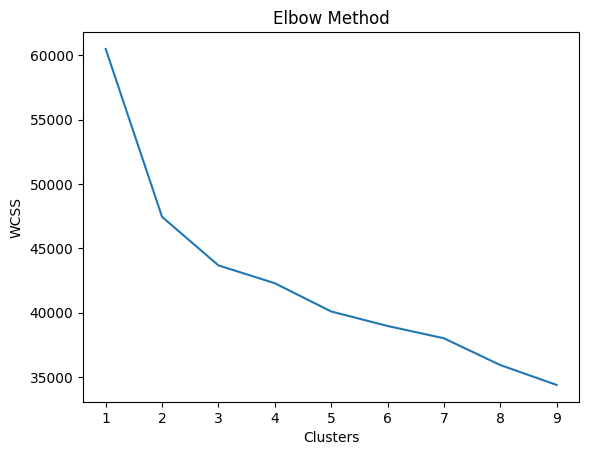

In [88]:
wcss = []
for i in range(1, 10):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss)
plt.title('Elbow Method')
plt.xlabel('Clusters')
plt.ylabel('WCSS')
plt.show()


Libraries imported successfully

Dataset Loaded
Shape of dataset: (2240, 29)

First 5 rows:
      ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014       94       173  ...                  5           

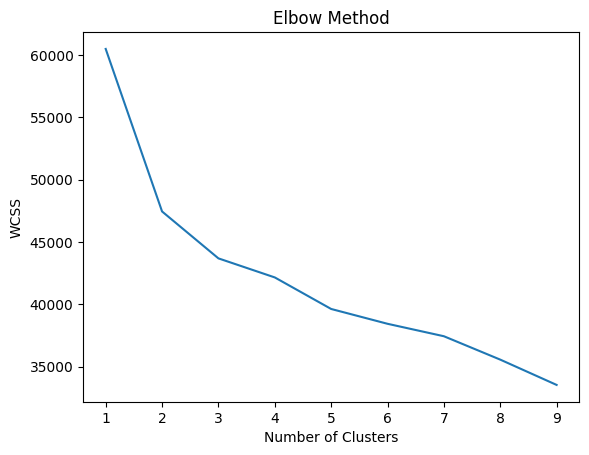


FINAL - Pipeline executed successfully 🚀


In [92]:
# ==========================================
# 1. IMPORT REQUIRED LIBRARIES
# ==========================================
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("\nLibraries imported successfully")


# ==========================================
# 2. LOAD DATASET
# ==========================================
df = pd.read_csv('Datasets/marketing_campaign.csv', sep='\t')

print("\nDataset Loaded")
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:\n", df.head())


# ==========================================
# 3. DATA UNDERSTANDING
# ==========================================
print("\nDataset Info")
print(df.info())

print("\nMissing Values:\n", df.isnull().sum())


# ==========================================
# 4. DATA CLEANING
# ==========================================

# Fill missing Income
df['Income'] = df['Income'].fillna(df['Income'].median(), inplace=True)

# Drop ID column (not useful for clustering)
df.drop(['ID'], axis=1, inplace=True)

print("\nData Cleaning Done")
print("Missing values after cleaning:\n", df.isnull().sum())


# ==========================================
# 5. FEATURE ENGINEERING
# ==========================================

# Convert date column
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')

# Create Age
df['Age'] = 2026 - df['Year_Birth']

# Customer duration
df['Customer_For'] = (pd.to_datetime('today') - df['Dt_Customer']).dt.days

# Total spending feature
df['Total_Spending'] = df[['MntWines', 'MntFruits', 'MntMeatProducts',
                          'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)

# Drop old columns
df.drop(['Year_Birth', 'Dt_Customer'], axis=1, inplace=True)

print("\nFeature Engineering Done")
print("New columns added: Age, Customer_For, Total_Spending")


# ==========================================
# 6. ENCODING CATEGORICAL VARIABLES
# ==========================================
le = LabelEncoder()

df['Education'] = le.fit_transform(df['Education'])
df['Marital_Status'] = le.fit_transform(df['Marital_Status'])

print("\nEncoding Done")
print("Categorical columns converted to numeric")


# ==========================================
# 7. FEATURE SCALING
# ==========================================
scaler = StandardScaler()
X = scaler.fit_transform(df)

print("\nFeature Scaling Done")
print("Data normalized using StandardScaler")


# ==========================================
# 8. K-MEANS CLUSTERING
# ==========================================
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

print("\nK-Means Clustering Applied")
print("Number of clusters formed:", len(set(kmeans_labels)))


# ==========================================
# 9. DBSCAN CLUSTERING
# ==========================================
dbscan = DBSCAN(eps=2.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

print("\nDBSCAN Clustering Applied")
print("Unique labels (including noise -1):", set(dbscan_labels))


# ==========================================
# 10. EVALUATION
# ==========================================

print("\n[STEP 10] Evaluating Models")

# ---- K-Means ----
kmeans_sil = silhouette_score(X, kmeans_labels)
kmeans_db = davies_bouldin_score(X, kmeans_labels)

print("\nK-Means Results:")
print("Silhouette Score (higher better):", round(kmeans_sil, 4))
print("Davies-Bouldin Index (lower better):", round(kmeans_db, 4))


# ---- DBSCAN ----
mask = dbscan_labels != -1  # remove noise

print("\nDBSCAN Results:")

if len(set(dbscan_labels[mask])) > 1:
    dbscan_sil = silhouette_score(X[mask], dbscan_labels[mask])
    dbscan_db = davies_bouldin_score(X[mask], dbscan_labels[mask])

    print("Silhouette Score:", round(dbscan_sil, 4))
    print("Davies-Bouldin Index:", round(dbscan_db, 4))
else:
    print("DBSCAN failed to form meaningful clusters (too much noise)")


# ==========================================
# 11. COMPARISON
# ==========================================
print("\nModel Comparison")

if len(set(dbscan_labels[mask])) > 1:
    if kmeans_sil > dbscan_sil:
        print("✅ K-Means performs better (higher silhouette score)")
    else:
        print("✅ DBSCAN performs better")
else:
    print("✅ K-Means performs better (DBSCAN failed)")


# ==========================================
# 12. ELBOW METHOD (OPTIONAL)
# ==========================================
print("\nFinding optimal clusters using Elbow Method")

wcss = []
for i in range(1, 10):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(X)
    wcss.append(km.inertia_)

plt.plot(range(1, 10), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()


print("\nFINAL - Pipeline executed successfully 🚀")